# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

d:\Python312\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

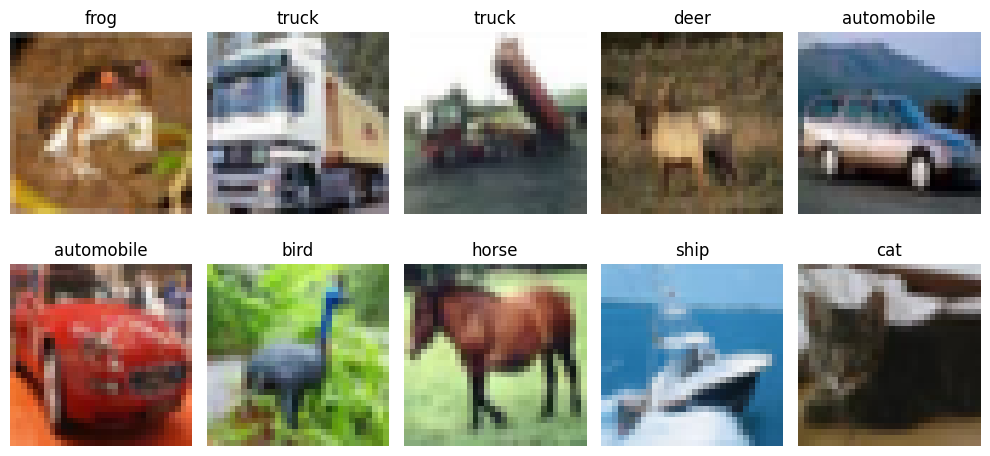

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

d:\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 41ms/step - accuracy: 0.2687 - loss: 2.0006 - val_accuracy: 0.3398 - val_loss: 1.8351
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.3123 - loss: 1.8857 - val_accuracy: 0.3644 - val_loss: 1.8096
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.3249 - loss: 1.8416 - val_accuracy: 0.3516 - val_loss: 1.7955
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.3420 - loss: 1.7978 - val_accuracy: 0.3678 - val_loss: 1.7526
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 55ms/step - accuracy: 0.3511 - loss: 1.7732 - val_accuracy: 0.4026 - val_loss: 1.7079
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 49ms/step - accuracy: 0.3635 - loss: 1.7466 - val_accuracy: 0.3926 - val_loss: 1.6999
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 36ms/step - accuracy: 0.3721 - loss: 1.7251 - val_accuracy: 0.4130 - val_loss: 1.6837
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.3731 - loss: 1.7166 - 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4222 - loss: 1.6407
ANN Test Accuracy: 0.4221999943256378


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

d:\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 107ms/step - accuracy: 0.4756 - loss: 1.4706 - val_accuracy: 0.5614 - val_loss: 1.2519
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 109ms/step - accuracy: 0.6118 - loss: 1.1053 - val_accuracy: 0.5132 - val_loss: 1.3976
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 110ms/step - accuracy: 0.6791 - loss: 0.9320 - val_accuracy: 0.6468 - val_loss: 1.0098
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 76s 108ms/step - accuracy: 0.7160 - loss: 0.8128 - val_accuracy: 0.6502 - val_loss: 1.0426
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 123ms/step - accuracy: 0.7493 - loss: 0.7231 - val_accuracy: 0.7314 - val_loss: 0.7892
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 62s 88ms/step - accuracy: 0.7732 - loss: 0.6449 - val_accuracy: 0.7260 - val_loss: 0.7843
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 68ms/step - accuracy: 0.7955 - loss: 0.5776 - val_accuracy: 0.7328 - val_loss: 0.8313
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 71ms/step - accuracy: 0.8192 - loss: 0.51

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7018 - loss: 1.0251
CNN Test Accuracy: 0.7017999887466431


## 📈 Compare Learning Curves

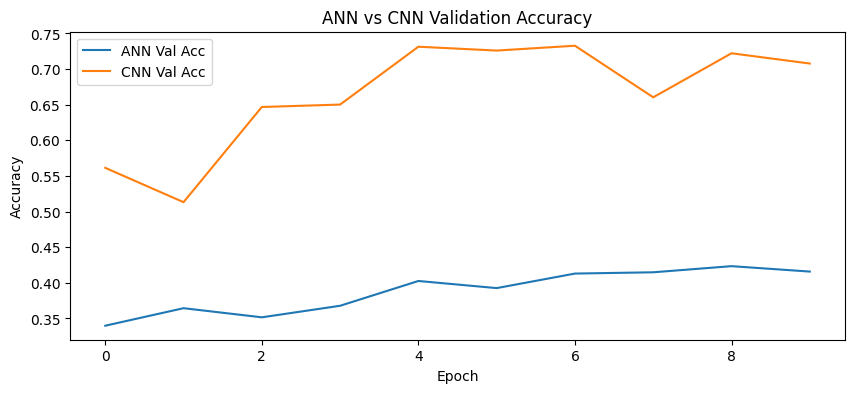

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [11]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4222
1,CNN,0.7018


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

---
# 🎓 Student Learning Tasks — Solutions
## All 5 beginner tasks implemented below
---

## ✅ Task 1: Increase ANN Layers and Observe Performance
We add more Dense layers (1024 → 512 → 256 → 128) with BatchNormalization and Dropout 
to build a deeper ANN and compare its performance against the original baseline ANN.

In [12]:
# Task 1: Deeper ANN with increased dense layers + BatchNormalization
# Adding more layers: 1024 -> 512 -> 256 -> 128 with BatchNorm for stable training

ann_v2 = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(10, activation='softmax')
])

ann_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_v2.summary()

d:\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,844,746 (14.67 MB)

 Trainable params: 3,840,906 (14.65 MB)

 Non-trainable params: 3,840 (15.00 KB)

In [13]:
# Train the deeper ANN for 10 epochs (batch_size=256 for faster CPU training)
ann_v2_history = ann_v2.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=256
)

# Evaluate on test set
ann_v2_loss, ann_v2_acc = ann_v2.evaluate(x_test_flat, y_test)
print(f"\nDeeper ANN Test Accuracy: {ann_v2_acc:.4f}")
print(f"Original ANN Test Accuracy: {ann_test_acc:.4f}")
print(f"Improvement: {(ann_v2_acc - ann_test_acc)*100:.2f}%")

Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 19s 83ms/step - accuracy: 0.2970 - loss: 2.0331 - val_accuracy: 0.3550 - val_loss: 1.8381
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 15s 85ms/step - accuracy: 0.3757 - loss: 1.7526 - val_accuracy: 0.2984 - val_loss: 1.9715
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 14s 80ms/step - accuracy: 0.4155 - loss: 1.6421 - val_accuracy: 0.3476 - val_loss: 1.8468
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 15s 85ms/step - accuracy: 0.4332 - loss: 1.5826 - val_accuracy: 0.3340 - val_loss: 1.8486
Epoch 5/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 15s 87ms/step - accuracy: 0.4496 - loss: 1.5415 - val_accuracy: 0.3962 - val_loss: 1.6814
Epoch 6/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 16s 90ms/step - accuracy: 0.4599 - loss: 1.5137 - val_accuracy: 0.3606 - val_loss: 1.7164
Epoch 7/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 15s 84ms/step - accuracy: 0.4661 - loss: 1.4965 - val_accuracy: 0.3910 - val_loss: 1.7034
Epoch 8/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 15s 85ms/step - accuracy: 0.4704 - loss: 1.4853 - 

## ✅ Task 2: Change CNN Filters from 32 → 64 → 128
We scale up the convolutional filter sizes to 64 → 128 → 256 with padding='same' 
to preserve spatial dimensions and BatchNormalization for training stability.

In [14]:
# Task 2: CNN with scaled-up filters (64 -> 128 -> 256)
# padding='same' preserves spatial dimensions for better feature extraction

cnn_v2 = models.Sequential([
    # Block 1 - 64 filters (scaled up from 32)
    layers.Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Block 2 - 128 filters (scaled up from 64)
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Block 3 - 256 filters (scaled up from 128)
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Classification head
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_v2.summary()

d:\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,424,010 (5.43 MB)

 Trainable params: 1,423,114 (5.43 MB)

 Non-trainable params: 896 (3.50 KB)

In [15]:
# Train the scaled CNN for 10 epochs (batch_size=256 for speed)
cnn_v2_history = cnn_v2.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=256
)

# Evaluate on test set
cnn_v2_loss, cnn_v2_acc = cnn_v2.evaluate(x_test_norm, y_test)
print(f"\nScaled CNN Test Accuracy: {cnn_v2_acc:.4f}")
print(f"Original CNN Test Accuracy: {cnn_test_acc:.4f}")
print(f"Improvement: {(cnn_v2_acc - cnn_test_acc)*100:.2f}%")

Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 157s 874ms/step - accuracy: 0.4403 - loss: 1.6120 - val_accuracy: 0.1186 - val_loss: 3.5378
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 153s 868ms/step - accuracy: 0.6040 - loss: 1.1182 - val_accuracy: 0.2398 - val_loss: 2.4427
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 153s 867ms/step - accuracy: 0.6784 - loss: 0.9151 - val_accuracy: 0.5734 - val_loss: 1.2446
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 159s 901ms/step - accuracy: 0.7289 - loss: 0.7799 - val_accuracy: 0.7024 - val_loss: 0.8535
Epoch 5/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 159s 906ms/step - accuracy: 0.7717 - loss: 0.6506 - val_accuracy: 0.7088 - val_loss: 0.8768
Epoch 6/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 160s 908ms/step - accuracy: 0.8023 - loss: 0.5571 - val_accuracy: 0.6998 - val_loss: 0.9180
Epoch 7/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 161s 914ms/step - accuracy: 0.8321 - loss: 0.4760 - val_accuracy: 0.7354 - val_loss: 0.8064
Epoch 8/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 161s 915ms/step - accuracy: 0.8604 -

## ✅ Task 3: Increase Epochs to 20
Training for 20 epochs with ReduceLROnPlateau callback which automatically reduces 
the learning rate when validation loss plateaus, enabling better convergence.

In [16]:
# Task 3: Train CNN for 20 epochs with learning rate scheduling
# ReduceLROnPlateau halves LR when val_loss stops improving

from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_reducer = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# Same architecture as Task 2 for fair comparison
cnn_20ep = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_20ep.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train for 20 epochs with batch_size=256 for faster CPU training
cnn_20ep_history = cnn_20ep.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=256,
    callbacks=[lr_reducer]
)

# Evaluate
cnn_20ep_loss, cnn_20ep_acc = cnn_20ep.evaluate(x_test_norm, y_test)
print(f"\nCNN (20 epochs) Test Accuracy: {cnn_20ep_acc:.4f}")
print(f"CNN (10 epochs) Test Accuracy: {cnn_test_acc:.4f}")

Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 153s 849ms/step - accuracy: 0.4304 - loss: 1.6810 - val_accuracy: 0.0968 - val_loss: 3.2133 - learning_rate: 0.0010
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 156s 888ms/step - accuracy: 0.5952 - loss: 1.1499 - val_accuracy: 0.2144 - val_loss: 2.6840 - learning_rate: 0.0010
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 158s 895ms/step - accuracy: 0.6699 - loss: 0.9443 - val_accuracy: 0.4410 - val_loss: 1.6390 - learning_rate: 0.0010
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 157s 891ms/step - accuracy: 0.7241 - loss: 0.7878 - val_accuracy: 0.6062 - val_loss: 1.1790 - learning_rate: 0.0010
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 157s 893ms/step - accuracy: 0.7662 - loss: 0.6703 - val_accuracy: 0.7178 - val_loss: 0.8220 - learning_rate: 0.0010
Epoch 6/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 158s 900ms/step - accuracy: 0.7978 - loss: 0.5719 - val_accuracy: 0.7192 - val_loss: 0.8335 - learning_rate: 0.0010
Epoch 7/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 206s 923ms/step - accura

## ✅ Task 4: Add EarlyStopping Callback
EarlyStopping monitors validation loss and stops training when the model stops improving. 
Combined with ReduceLROnPlateau for optimal training. Uses patience=5 and restore_best_weights=True.

In [17]:
# Task 4: CNN with EarlyStopping + ReduceLROnPlateau callbacks
# EarlyStopping prevents overfitting, ReduceLROnPlateau fine-tunes learning rate

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_reducer_es = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

cnn_es = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_es.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train with both callbacks (batch_size=256 for speed)
cnn_es_history = cnn_es.fit(
    x_train_norm, y_train,
    epochs=25,
    validation_split=0.1,
    batch_size=256,
    callbacks=[early_stop, lr_reducer_es]
)

# Evaluate
cnn_es_loss, cnn_es_acc = cnn_es.evaluate(x_test_norm, y_test)
print(f"\nCNN + EarlyStopping Test Accuracy: {cnn_es_acc:.4f}")
print(f"Training stopped at epoch: {len(cnn_es_history.history['loss'])}")

Epoch 1/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 160s 888ms/step - accuracy: 0.4429 - loss: 1.6008 - val_accuracy: 0.0956 - val_loss: 3.5870 - learning_rate: 0.0010
Epoch 2/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 154s 876ms/step - accuracy: 0.5991 - loss: 1.1335 - val_accuracy: 0.1018 - val_loss: 3.6028 - learning_rate: 0.0010
Epoch 3/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 158s 897ms/step - accuracy: 0.6749 - loss: 0.9248 - val_accuracy: 0.5798 - val_loss: 1.2254 - learning_rate: 0.0010
Epoch 4/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 151s 858ms/step - accuracy: 0.7246 - loss: 0.7842 - val_accuracy: 0.6754 - val_loss: 0.9723 - learning_rate: 0.0010
Epoch 5/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 152s 863ms/step - accuracy: 0.7625 - loss: 0.6706 - val_accuracy: 0.6694 - val_loss: 1.0251 - learning_rate: 0.0010
Epoch 6/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 161s 917ms/step - accuracy: 0.7988 - loss: 0.5698 - val_accuracy: 0.7444 - val_loss: 0.7701 - learning_rate: 0.0010
Epoch 7/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 158s 896ms/step - accura

## ✅ Task 5: Run Data Augmentation Training
We train the augmented CNN model (defined earlier) with EarlyStopping and ReduceLROnPlateau. 
Data augmentation (RandomFlip, RandomRotation, RandomZoom) creates diverse training samples 
on-the-fly, helping the model generalize better to unseen data.

In [18]:
# Task 5: Train the augmented CNN model (defined earlier in the notebook)
# The aug_cnn_model uses RandomFlip, RandomRotation, RandomZoom layers

early_stop_aug = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_reducer_aug = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# Train augmented model (batch_size=256 for speed)
aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=25,
    validation_split=0.1,
    batch_size=256,
    callbacks=[early_stop_aug, lr_reducer_aug]
)

# Evaluate the augmented model
aug_loss, aug_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print(f"\nAugmented CNN Test Accuracy: {aug_acc:.4f}")
print(f"Training stopped at epoch: {len(aug_history.history['loss'])}")

Epoch 1/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 20s 99ms/step - accuracy: 0.2896 - loss: 1.9336 - val_accuracy: 0.4188 - val_loss: 1.6022 - learning_rate: 0.0010
Epoch 2/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 17s 96ms/step - accuracy: 0.4032 - loss: 1.6442 - val_accuracy: 0.4256 - val_loss: 1.5803 - learning_rate: 0.0010
Epoch 3/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 17s 96ms/step - accuracy: 0.4393 - loss: 1.5523 - val_accuracy: 0.4432 - val_loss: 1.5223 - learning_rate: 0.0010
Epoch 4/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 17s 98ms/step - accuracy: 0.4625 - loss: 1.4874 - val_accuracy: 0.5234 - val_loss: 1.3241 - learning_rate: 0.0010
Epoch 5/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 17s 98ms/step - accuracy: 0.4787 - loss: 1.4392 - val_accuracy: 0.5180 - val_loss: 1.3361 - learning_rate: 0.0010
Epoch 6/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 17s 97ms/step - accuracy: 0.4953 - loss: 1.4054 - val_accuracy: 0.5418 - val_loss: 1.2640 - learning_rate: 0.0010
Epoch 7/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 18s 100ms/step - accuracy: 0.5064 - 

---
## 📊 Final Comparison — All Model Variants
Comprehensive comparison of test accuracy across all architectures and training strategies.

In [19]:
# Final comparison table for all model variants
final_comparison = pd.DataFrame({
    "Model": [
        "ANN (Baseline)",
        "ANN (Deeper - Task 1)",
        "CNN (Baseline)",
        "CNN Scaled Filters (Task 2)",
        "CNN 20 Epochs (Task 3)",
        "CNN + EarlyStopping (Task 4)",
        "CNN + Augmentation (Task 5)"
    ],
    "Test Accuracy": [
        round(ann_test_acc, 4),
        round(ann_v2_acc, 4),
        round(cnn_test_acc, 4),
        round(cnn_v2_acc, 4),
        round(cnn_20ep_acc, 4),
        round(cnn_es_acc, 4),
        round(aug_acc, 4)
    ]
})

print("="*55)
print("  CIFAR-10 Model Performance Comparison")
print("="*55)
final_comparison

  CIFAR-10 Model Performance Comparison


,Model,Test Accuracy
0,ANN (Baseline),0.4222
1,ANN (Deeper - Task 1),0.4146
2,CNN (Baseline),0.7018
3,CNN Scaled Filters (Task 2),0.7377
4,CNN 20 Epochs (Task 3),0.8083
5,CNN + EarlyStopping (Task 4),0.7810
6,CNN + Augmentation (Task 5),0.6166


## 📈 Validation Accuracy Curves — All Models
Validation accuracy tracking across all trained model variants.

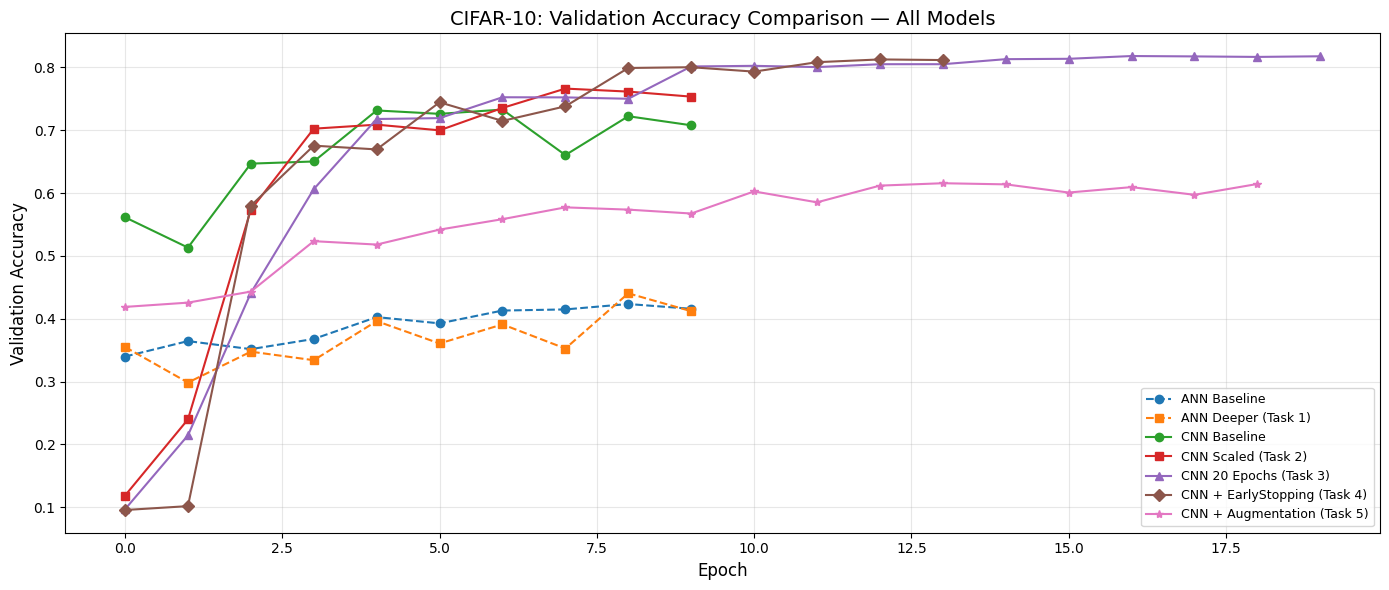

In [20]:
# Plot validation accuracy for all model variants
plt.figure(figsize=(14, 6))

plt.plot(ann_history.history['val_accuracy'], label='ANN Baseline', linestyle='--', marker='o')
plt.plot(ann_v2_history.history['val_accuracy'], label='ANN Deeper (Task 1)', linestyle='--', marker='s')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Baseline', marker='o')
plt.plot(cnn_v2_history.history['val_accuracy'], label='CNN Scaled (Task 2)', marker='s')
plt.plot(cnn_20ep_history.history['val_accuracy'], label='CNN 20 Epochs (Task 3)', marker='^')
plt.plot(cnn_es_history.history['val_accuracy'], label='CNN + EarlyStopping (Task 4)', marker='D')
plt.plot(aug_history.history['val_accuracy'], label='CNN + Augmentation (Task 5)', marker='*')

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.title('CIFAR-10: Validation Accuracy Comparison — All Models', fontsize=14)
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 📉 Training vs Validation Loss Curves
Loss curves help diagnose overfitting — when training loss drops but validation loss rises.

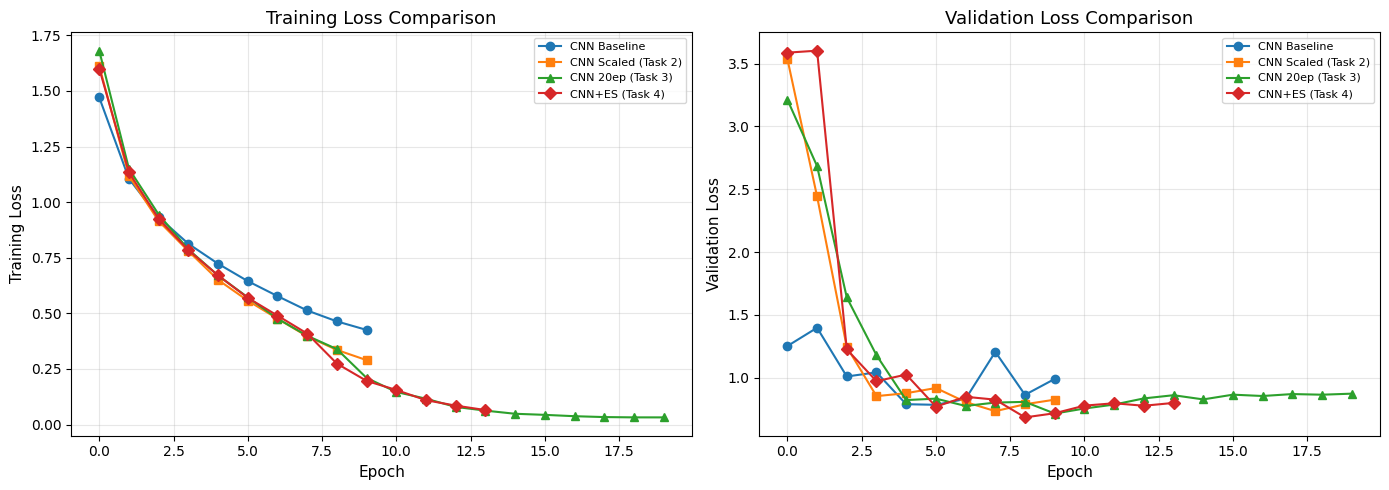

In [21]:
# Plot training and validation loss for CNN models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training Loss
axes[0].plot(cnn_history.history['loss'], label='CNN Baseline', marker='o')
axes[0].plot(cnn_v2_history.history['loss'], label='CNN Scaled (Task 2)', marker='s')
axes[0].plot(cnn_20ep_history.history['loss'], label='CNN 20ep (Task 3)', marker='^')
axes[0].plot(cnn_es_history.history['loss'], label='CNN+ES (Task 4)', marker='D')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Training Loss', fontsize=11)
axes[0].set_title('Training Loss Comparison', fontsize=13)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Validation Loss
axes[1].plot(cnn_history.history['val_loss'], label='CNN Baseline', marker='o')
axes[1].plot(cnn_v2_history.history['val_loss'], label='CNN Scaled (Task 2)', marker='s')
axes[1].plot(cnn_20ep_history.history['val_loss'], label='CNN 20ep (Task 3)', marker='^')
axes[1].plot(cnn_es_history.history['val_loss'], label='CNN+ES (Task 4)', marker='D')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Validation Loss', fontsize=11)
axes[1].set_title('Validation Loss Comparison', fontsize=13)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**